![Banner PTI Clima](https://raw.githubusercontent.com/SantanderMetGroup/PTI-Clima-Datalab/devel/aux/Banner-logos-PTIClima-ProyectoServiciosAEMET.png)

# Datalab de la Plataforma Estatal de Servicios Climáticos 

***
> Los cuadernos (Jupyter Notebooks) incluidos en este Datalab muestran ejemplos prácticos para utilizar, transformar y visualizar los conjuntos de datos disponibles en el [almacén de datos](https://pti.climate.ifca.es/data) de la Plataforma Estatal de Servicios Climáticos.
>
> Este trabajo está licenciado bajo una [Licencia Creative Commons Atribución 4.0 Internacional](http://creativecommons.org/licenses/by/4.0).
>
> ![Licencia de Creative Commons](https://i.creativecommons.org/l/by/4.0/88x31.png)


## Guía para la intercomparación de rejillas observacionales: Península Ibérica

**M. Iturbide, M.ª I. de la Osa Rocha** (Instituto de Física de Cantabria, CSIC-Universidad de Cantabria, Santander, Spain).

En este notebook verás cómo intercomparar los diferentes conjuntos de datos observacionales disponibles en el Almacén de Datos de la Plataforma Estatal de Servicios Climáticos para la Península Ibérica. Este notebook tiene como objetivo principal facilitar su reutilización y asegurar la reproducibilidad de los productos climáticos. La guía recorre los pasos esenciales para acceder a los datos, definir peticiones de carga, realizar transformaciones básicas y visualizar los resultados.

La Plataforma Virtual de Cálculo ofrece, además, un **notebook de primeros pasos** y una **colección de notebooks temáticos** (p. ej., intercomparación de conjuntos de datos observacionales o cálculo de índices) que puedes consultar para ampliar el uso de las herramientas y profundizar en los análisis a partir de los datos disponibles en el Almacén.

Todo el flujo de trabajo se realiza con ***climate4R***, un framework de librerías en R para la carga, el postprocesamiento y el análisis de datos climáticos.

<img src="https://raw.githubusercontent.com/SantanderMetGroup/climate4R/refs/heads/devel/man/figures/climate4R_logo.svg" alt="Description" width="60" height="40">

***climate4R*** ofrece más funcionalidades de las que se ilustran en este notebook, como **funcionalidades de operaciones espaciales y temporales** o como **interpolación, subsetting o intersección espacial**. Además, brinda funcionalidades para la **corrección de sesgo y downscaling** o funciones específicas para el **cálculo del FWI**. Consulta [Iturbide et al., 2019](https://www.sciencedirect.com/science/article/pii/S1364815218303049?via%3Dihub) y el repositorio de [github de climate4R](https://github.com/SantanderMetGroup/climate4R) para más información.

### Contenido de este cuaderno
1) Carga de librerías
2) Selección de conjuntos de datos  
3) Carga de datos
4) Carga y armonización de varios datasets
   * 4.1. Interpolación a una malla común y unión de varios datasets en un único objeto grid
5) Análisis básico
   * 5.1. Medias climatológicas
   * 5.2. Series temporales 
7) Session Info

Antes de empezar definiremos el heap space de java.

In [1]:
options(java.parameters = "-Xmx20g")

Antes de empezar, o en cualquier momento durante el cuaderno, podemos personalizar el área de visualización de gráficos de la siguiente manera:

In [2]:
library(repr)
# Change plot size 
options(repr.plot.width=20, repr.plot.height=5)

***

### 1. Carga de librerías

Las librerías/paquetes centrales de ***climate4R*** que permiten **cargar y transformar** datos (p. ej., agregaciones espaciotemporales) y **visualizarlos** son `loadeR`, `transformeR` y `visualizeR`.

In [3]:
library(loadeR)
library(transformeR)
library(visualizeR)

Loading required package: rJava

Loading required package: loadeR.java

Java version 22x amd64 by N/A detected

NetCDF Java Library v4.6.0-SNAPSHOT (23 Apr 2015) loaded and ready

Loading required package: climate4R.UDG

climate4R.UDG version 0.2.6 (2023-06-26) is loaded

Please use 'citation("climate4R.UDG")' to cite this package.

loadeR version 1.8.1 (2023-06-22) is loaded


Get the latest stable version (1.8.2) using <devtools::install_github(c('SantanderMetGroup/climate4R.UDG','SantanderMetGroup/loadeR'))>

Please use 'citation("loadeR")' to cite this package.




    _______   ____  ___________________  __  ________ 
   / ___/ /  / /  |/  / __  /_  __/ __/ / / / / __  / 
  / /  / /  / / /|_/ / /_/ / / / / __/ / /_/ / /_/_/  
 / /__/ /__/ / /  / / __  / / / / /__ /___  / / \ \ 
 \___/____/_/_/  /_/_/ /_/ /_/  \___/    /_/\/   \_\ 
 
      github.com/SantanderMetGroup/climate4R



transformeR version 2.2.2 (2023-10-26) is loaded


Get the latest stable version (2.2.5) using <devtools::install_github('SantanderMetGroup/transformeR')>

Please see 'citation("transformeR")' to cite this package.

visualizeR version 1.6.4 (2023-10-26) is loaded

Please see 'citation("visualizeR")' to cite this package.



Sin embargo, el software incluye todo el framework *climate4R* y otras bibliotecas útiles. Por ejemplo, incluye la potente biblioteca de gráficos `lattice` o la biblioteca `magrittr` para operaciones en tuberías (a través de `%>%`).

In [4]:
library(lattice)
library(magrittr)
library(gridExtra)

### 2. Selección de conjuntos de datos

El inventario (`data_inventory.csv`) cataloga la lista de archivos del [**Almacén de datos de la PTI-Clima**](https://pti.climate.ifca.es/data).

Simplemente necesitamos leer este archivo con la función `read.csv` para obtener el `data.frame` con esta información.

In [5]:
df <- read.csv("../../data_inventory.csv")

In [6]:
str(df)

'data.frame':	459 obs. of  9 variables:
 $ dataset   : chr  "AEMET-ROCIO-IBEB-regular_Iberia_day" "AEMET-ROCIO-CAN-regular_Canarias_day" "CHELSA-W5E5v1.0_Canarias_day" "CHELSA-W5E5v1.0_Iberia_day" ...
 $ type      : chr  "observations" "observations" "observations" "observations" ...
 $ access    : chr  "opendap" "opendap" "opendap" "opendap" ...
 $ source    : chr  "AEMET-ROCIO-IBEB-regular" "AEMET-ROCIO-CAN-regular" "CHELSA-W5E5v1.0" "CHELSA-W5E5v1.0" ...
 $ provider  : chr  "" "" "" "" ...
 $ experiment: chr  "" "" "" "" ...
 $ frequency : chr  "day" "day" "day" "day" ...
 $ endpoint  : chr  "https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/AEMET-ROCIO-IBEB/Iberia/day/AEMET-RO"| __truncated__ "https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/AEMET-ROCIO-CAN/Canarias/day/AEMET-R"| __truncated__ "https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/CHELSA-W5E5v1.0/Canarias/day/CHELSA-"| __truncated__ "https://th

Podremos ver las primeras filas del `data.frame` resultande con la función `head`.

In [7]:
head(df)

,dataset,type,access,source,provider,experiment,frequency,endpoint,dictionary
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,AEMET-ROCIO-IBEB-regular_Iberia_day,observations,opendap,AEMET-ROCIO-IBEB-regular,,,day,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/AEMET-ROCIO-IBEB/Iberia/day/AEMET-ROCIO-IBEB_Iberia_day.ncml,../../Harmonization_dictionaries/AEMET-ROCIO-regular.dic
2,AEMET-ROCIO-CAN-regular_Canarias_day,observations,opendap,AEMET-ROCIO-CAN-regular,,,day,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/AEMET-ROCIO-CAN/Canarias/day/AEMET-ROCIO-CAN_Canarias_day.ncml,../../Harmonization_dictionaries/AEMET-ROCIO-regular.dic
3,CHELSA-W5E5v1.0_Canarias_day,observations,opendap,CHELSA-W5E5v1.0,,,day,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/CHELSA-W5E5v1.0/Canarias/day/CHELSA-W5E5v1.0_Canarias_day.ncml,../../Harmonization_dictionaries/CHELSA-W5E5v1.0.dic
4,CHELSA-W5E5v1.0_Iberia_day,observations,opendap,CHELSA-W5E5v1.0,,,day,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/CHELSA-W5E5v1.0/Iberia/day/CHELSA-W5E5v1.0_Iberia_day.ncml,../../Harmonization_dictionaries/CHELSA-W5E5v1.0.dic
5,PTI-grid-v0_Canarias_day,observations,opendap,PTI-grid-v0,,,day,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/PTI-grid-v0/Canarias/day/PTI-grid-v0_Canarias_day.ncml,../../Harmonization_dictionaries/PTI-grid-v0.dic
6,PTI-grid-v0_Iberia_day,observations,opendap,PTI-grid-v0,,,day,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/PTI-grid-v0/Iberia/day/PTI-grid-v0_Iberia_day.ncml,../../Harmonization_dictionaries/PTI-grid-v0.dic


Se observan diferentes columnas o campos que describen los datos:

* `dataset` se refiere al nombre que se le da a cada instancia de datos en el almacén.
* `type` se refiere al tipo de los conjuntos de datos, ya sea "observaciones" (observations), "reanalisis" (reanalysis) o proyecciones (projections).
* `source` se refiere al conjuntos de datos de origen (p. ej., CORDEX-EUR, CMIP5, CMIP6, etc.).  
* `provider` se refiere a la entidad distribuidora de donde se obtuvieron los datos originales.  
* `access` se refiere al modo de acceso, ya sea local (netcdf) o remoto (opendap).
* `experiment` se refiere al escenario (p. ej., historical, rcp26, ssp126, rcp85, etc.).
* `frequency` se refiere a la escala temporal de los datos.
* `endpoint` se refiere a la ruta del archivo de datos. Esta ruta es la que se utilizará para cargar los datos más adelante.
* `dictionary` se refiere al archivo que determina el tipo de conversiones necesarias (unidades y nombre de variable) para cargar los datos de manera armonizada, independientemente de las características diferenciadas de los datasets en origen.

Podemos **aplicar fácilmente filtros** para obtener el archivo deseado. El objetivo de este notebook es intercomparar las rejillas observacionales disponibles (incluyendo reanalysis), por lo tanto, filtraremos el catálogo de datos por tipo (`type`). Nos quedaremos con el nombre del `dataset`, el `endpoint` y el `dictionary`.

In [8]:
obs <- subset(df, type == "observations")[c("dataset", "endpoint", "dictionary")]
rea <- subset(df, type == "reanalysis")[c("dataset", "endpoint", "dictionary")]
datasets <- rbind(obs, rea) %>% print

                                 dataset
1    AEMET-ROCIO-IBEB-regular_Iberia_day
2   AEMET-ROCIO-CAN-regular_Canarias_day
3           CHELSA-W5E5v1.0_Canarias_day
4             CHELSA-W5E5v1.0_Iberia_day
5               PTI-grid-v0_Canarias_day
6                 PTI-grid-v0_Iberia_day
7               PTI-grid-v1_Canarias_day
8                 PTI-grid-v1_Iberia_day
9               PTI-grid-v2_Canarias_day
10                PTI-grid-v2_Iberia_day
11              PTI-grid-v4_Canarias_day
12                PTI-grid-v4_Iberia_day
13                 PTI-grid_Canarias_day
14                   PTI-grid_Iberia_day
15          PTI-indices_Iberia_clim-year
16           PTI-indices_Iberia_clim-mon
17                PTI-indices_Iberia_mon
18               PTI-indices_Iberia_year
19             PTI-indices_Iberia_season
20        PTI-indices_Canarias_clim-year
21         PTI-indices_Canarias_clim-mon
22              PTI-indices_Canarias_mon
23             PTI-indices_Canarias_year
24           PTI

En este caso, optaremos por la región de España peninsular y Baleares (consulta el notebook `intercomp_rejillas_obs_Canarias_R` para el ejemplo centrado en Canarias). Estos son los datasets que contienen `Iberia` en su nombre.

In [9]:
ind <- grep("Iberia", datasets$dataset)
datasets <- datasets[ind,] %>% print

                                dataset
1   AEMET-ROCIO-IBEB-regular_Iberia_day
4            CHELSA-W5E5v1.0_Iberia_day
6                PTI-grid-v0_Iberia_day
8                PTI-grid-v1_Iberia_day
10               PTI-grid-v2_Iberia_day
12               PTI-grid-v4_Iberia_day
14                  PTI-grid_Iberia_day
15         PTI-indices_Iberia_clim-year
16          PTI-indices_Iberia_clim-mon
17               PTI-indices_Iberia_mon
18              PTI-indices_Iberia_year
19            PTI-indices_Iberia_season
137                ERA5-Land_Iberia_day
                                                                                                                                   endpoint
1   https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/AEMET-ROCIO-IBEB/Iberia/day/AEMET-ROCIO-IBEB_Iberia_day.ncml
4     https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/CHELSA-W5E5v1.0/Iberia/day/CHELSA-W5E5v1.0_Iberia_day.ncml
6             https:

Por simplicidad y rapidez, no incluiremos `CHELSA-W5E5v1.0_Iberia_day` en este notebook ilustrativo. 

In [10]:
ind <- grep("CHELSA", datasets$dataset, invert = T)
datasets <- datasets[ind,] %>% print

                                dataset
1   AEMET-ROCIO-IBEB-regular_Iberia_day
6                PTI-grid-v0_Iberia_day
8                PTI-grid-v1_Iberia_day
10               PTI-grid-v2_Iberia_day
12               PTI-grid-v4_Iberia_day
14                  PTI-grid_Iberia_day
15         PTI-indices_Iberia_clim-year
16          PTI-indices_Iberia_clim-mon
17               PTI-indices_Iberia_mon
18              PTI-indices_Iberia_year
19            PTI-indices_Iberia_season
137                ERA5-Land_Iberia_day
                                                                                                                                   endpoint
1   https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/AEMET-ROCIO-IBEB/Iberia/day/AEMET-ROCIO-IBEB_Iberia_day.ncml
6             https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/PTI-grid-v0/Iberia/day/PTI-grid-v0_Iberia_day.ncml
8             https://thredds.climate.ifca.es/thredds/dodsC/

De manera similar, excluiremos los datasets `PTI-indices_*` de este notebook, ya que corresponden a índices climáticos derivados y no a rejillas observacionales 
de variables base.

In [11]:
ind <- grep("PTI-indices", datasets$dataset, invert = TRUE)
datasets <- datasets[ind, ] %>% print

                                dataset
1   AEMET-ROCIO-IBEB-regular_Iberia_day
6                PTI-grid-v0_Iberia_day
8                PTI-grid-v1_Iberia_day
10               PTI-grid-v2_Iberia_day
12               PTI-grid-v4_Iberia_day
14                  PTI-grid_Iberia_day
137                ERA5-Land_Iberia_day
                                                                                                                                   endpoint
1   https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/AEMET-ROCIO-IBEB/Iberia/day/AEMET-ROCIO-IBEB_Iberia_day.ncml
6             https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/PTI-grid-v0/Iberia/day/PTI-grid-v0_Iberia_day.ncml
8             https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/PTI-grid-v1/Iberia/day/PTI-grid-v1_Iberia_day.ncml
10            https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/PTI-grid-v2/Iberia/day/PTI-grid

Una vez que tenemos los datasets y sus `endpoint`, podemos mostrar fácilmente las características de los datos que contienen. Para hacerlo, empleamos la función `dataInventory` del paquete `loadeR`. Por ejemplo, para el dataset **AEMET-ROCIO-IBEB-regular_Iberia_day**, realizaremos el inventario de la siguiente manera.

In [12]:
rocio.endpoint <- subset(datasets, dataset == "AEMET-ROCIO-IBEB-regular_Iberia_day")[["endpoint"]]
di <- dataInventory(rocio.endpoint)

[2026-06-02 13:34:32.582945] Doing inventory ...

[2026-06-02 13:34:32.666439] Opening dataset...

[2026-06-02 13:34:33.884462] The dataset was successfuly opened

[2026-06-02 13:34:34.024341] Retrieving info for 'tasmax' (2 vars remaining)

[2026-06-02 13:34:34.165553] Retrieving info for 'pr' (1 vars remaining)

[2026-06-02 13:34:34.232656] Retrieving info for 'tasmin' (0 vars remaining)

[2026-06-02 13:34:34.302231] Done.



Podemos echar un primer vistazo a la información disponible con `str`.

In [13]:
str(di)

List of 3
 $ tasmax:List of 7
  ..$ Description: chr "temperature"
  ..$ DataType   : chr "float"
  ..$ Shape      : int [1:3] 26298 170 273
  ..$ Units      : chr "C"
  ..$ DataSizeMb : num 4882
  ..$ Version    : logi NA
  ..$ Dimensions :List of 3
  .. ..$ time:List of 4
  .. .. ..$ Type      : chr "Time"
  .. .. ..$ TimeStep  : chr "1.0 days"
  .. .. ..$ Units     : chr "days since 1951-01-01 00:00:00"
  .. .. ..$ Date_range: chr "1951-01-01T00:00:00Z - 2022-12-31T00:00:00Z"
  .. ..$ lat :List of 5
  .. .. ..$ Type       : chr "Lat"
  .. .. ..$ Units      : chr "degrees_north"
  .. .. ..$ Values     : num [1:170] 35.3 35.3 35.4 35.4 35.5 ...
  .. .. ..$ Shape      : int 170
  .. .. ..$ Coordinates: chr "lat"
  .. ..$ lon :List of 5
  .. .. ..$ Type       : chr "Lon"
  .. .. ..$ Units      : chr "degrees_east"
  .. .. ..$ Values     : num [1:273] -9.32 -9.27 -9.22 -9.17 -9.12 ...
  .. .. ..$ Shape      : int 273
  .. .. ..$ Coordinates: chr "lon"
 $ pr    :List of 7
  ..$ Descriptio

Vemos que, para este dataset, hay tres variables disponibles: pr, tasmax y tasmin. Para cada una de ellas se detalla información adicional, como las unidades,el periodo temporal que cubren, las coordenadas, resolución, etc.

### 3. Carga de datos


La carga de datos se realiza mediante la **función `loadGridData`** especificando, como fuente de datos, la ruta de un archivo NetCDF o de un catálogo NcML. En nuestro caso, esa ruta es precisamente lo que encapsula el objeto **`endpoint`** que hemos definido anteriormente.

çTambién **es necesario especificar el parámetro `var`**, que en este ejemplo se establece como `tasmax` (temperatura superficial maxima). Ten en cuenta que **`loadGridData` permite establecer parámetros adicionales**. Por ejemplo, podríamos utilizar los parámetros `lonLim` y `latLim` para cargar únicamente el subconjunto de datos correspondiente a una región más pequeña. Si no se emplean estos parámetros se carga el dominio completo (como en este caso). Otro parámetro útil es `season`, para cargar datos de meses específicos (en este ejemplo, JJA para el verano boreal). En el parámetro `years`, especificamos el periodo deseado (en este caso, 1991-2020). El parámetro que habilita la carga de datos armonizados es `dictionary`. **Para obtener detalles sobre el funcionamiento de los diccionarios, puedes consultar el notebook `primeros_pasos_R.ipynb`**.

Ejecuta `help(loadGridData)` para consultar otros parámetros disponibles.  

La carga de datos puede tardar segundos o minutos dependiendo de la cantidad de datos que corresponda a la petición que hagamos. A continuación ilustramos la carga de datos de `AEMET-ROCIO-IBEB-regular_Iberia_day`, definiendo previamente el `endpoint` y el `dictionary` concretos de este dataset.

In [14]:
dataset.i <- "AEMET-ROCIO-IBEB-regular_Iberia_day"
endpoint.i <- subset(datasets, dataset == dataset.i)[["endpoint"]]
dic.i <- subset(datasets, dataset == dataset.i)[["dictionary"]]

In [15]:
tasmax.jja.rocio <- loadGridData(dataset = endpoint.i,
                           var = "tasmax",
                           season = 6:8,
                           years = 1991:2020,
                           dictionary = dic.i)

[2026-06-02 13:34:58.767373] Defining harmonization parameters for variable "tasmax"

[2026-06-02 13:34:58.854507] Opening dataset...

[2026-06-02 13:34:58.994619] The dataset was successfuly opened

[2026-06-02 13:34:59.001386] Defining geo-location parameters

[2026-06-02 13:34:59.099439] Defining time selection parameters

[2026-06-02 13:34:59.342105] Retrieving data subset ...

[2026-06-02 13:36:07.915198] Done



Obtenemos así un `grid` de `climate4R` con el que podemos operar de manera transparente (Consulta `primeros_pasos_R.ipynb` para más detalles), por ejemplo para generar el mapa de la media climatológica:

[2026-06-02 13:36:09.407162] - Computing climatology...

[2026-06-02 13:36:13.773769] - Done.



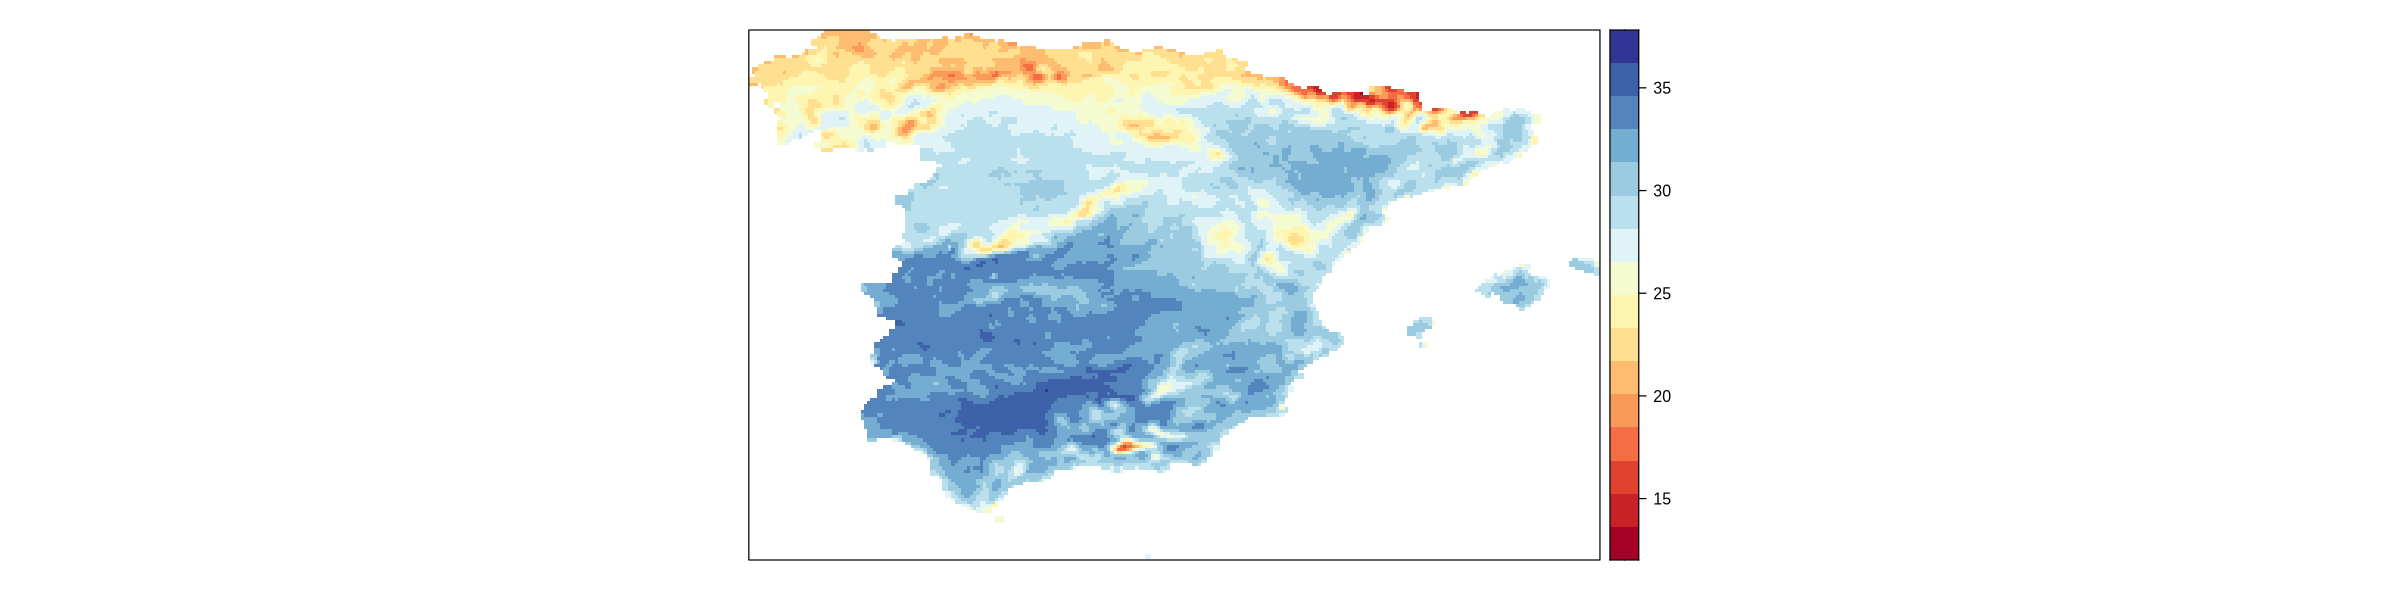

In [16]:
spatialPlot(climatology(tasmax.jja.rocio))

### 4. Carga y armonización de varios datasets

Si queremos proceder de manera más eficiente, podemos **automatizar la carga en un bucle**. Primero, necesitamos conocer el **periodo de tiempo que comparten los diferentes datasets**. Para ello, podemos recurrir nuevamente a `dataInventory`, aplicado en un bucle esta vez. Extraeremos el atributo `Date_range`. Con extraer esta información para una de las variables (e.g. `di[[2]]`) es suficiente. También utilizaremos la función `suppressMessages` para evitar una larga lista de mensajes de salida.

In [17]:
di.all <- lapply(datasets$endpoint, function(d){
    message("processing...", d)
    di <- dataInventory(d) %>% suppressMessages %>% suppressWarnings
    di[[2]]$Dimensions$time$Date_range %>% suppressMessages 
}) 
names(di.all) <- datasets$dataset
str(di.all)

processing...https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/AEMET-ROCIO-IBEB/Iberia/day/AEMET-ROCIO-IBEB_Iberia_day.ncml

processing...https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/PTI-grid-v0/Iberia/day/PTI-grid-v0_Iberia_day.ncml

processing...https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/PTI-grid-v1/Iberia/day/PTI-grid-v1_Iberia_day.ncml

processing...https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/PTI-grid-v2/Iberia/day/PTI-grid-v2_Iberia_day.ncml

processing...https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/PTI-grid-v4/Iberia/day/PTI-grid-v4_Iberia_day.ncml

processing...https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/PTI-grid/Iberia/day/PTI-grid_Iberia_day.ncml

processing...https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/REANALYSIS/ERA5-Land/Iberia/day/ERA5-Land_Iberia_day.ncml



List of 7
 $ AEMET-ROCIO-IBEB-regular_Iberia_day: chr "1951-01-01T00:00:00Z - 2022-12-31T00:00:00Z"
 $ PTI-grid-v0_Iberia_day             : chr "1961-01-01T00:00:00Z - 2022-12-31T00:00:00Z"
 $ PTI-grid-v1_Iberia_day             : chr "1961-01-01T00:00:00Z - 2022-12-31T00:00:00Z"
 $ PTI-grid-v2_Iberia_day             : chr "1961-01-01T00:00:00Z - 2024-12-31T00:00:00Z"
 $ PTI-grid-v4_Iberia_day             : chr "1961-01-01T00:00:00Z - 2025-10-31T00:00:00Z"
 $ PTI-grid_Iberia_day                : chr "1961-01-01T01:00:00Z - 2026-02-27T01:00:00Z"
 $ ERA5-Land_Iberia_day               : chr "1950-01-01T00:00:00Z - 2021-12-31T00:00:00Z"


Como podemos ver en el resultado obtenidotodos los datasets cubren el periodo que habíamos definido previamente (1991-2020). Dado que cargar varios datasets para un periodo de 30 años ocupa mucha memoria, intentaremos reducir la carga sin comprometer los objetivos del análisis. En nuestro caso, no necesitamos el dato diario, así que realizaremos la agregación mensual en el momento de la carga con el arguento `aggr.m`, extrayendo el máximo de la temperatura máxima de cada mes. Además, utilizaremos los parámetros `lonLim` y `latLim`, para asegurarnos de que cargamos el mismo dominio en cada caso. Para ello, utilizaremos `AEMET-ROCIO-IBEB-regular_Iberia_day` como referencia.

In [18]:
di.ref <- dataInventory(subset(datasets, dataset == "AEMET-ROCIO-IBEB-regular_Iberia_day")[["endpoint"]]) %>% 
    suppressMessages %>% suppressWarnings
latLim <- di.ref$pr$Dimensions$lat$Values %>% range
lonLim <- di.ref$pr$Dimensions$lon$Values %>% range

Ya podemos **realizar la carga**. Ten en cuenta que **esta operación puede tardar minutos**, ya que estamos cargando una gran cantidad de datos. Puedes guardar el objeto generado para evitar repetir esta operación en el futuro. Por ese motivo se incluye un `if` que comprueba si el objeto está creado anteriormente, y ejecuta la carga únicamente si el objeto no está en la ruta indicada (puedes modificar la ruta de `resulting.object.path`).

In [20]:
resulting.object.path <- "../../../tasmax.jja.rds"

if (!file.exists(resulting.object.path)) {
    
    tasmax.jja <- lapply(datasets$dataset, function(d) {
        dataset.i <- d
        endpoint.i <- subset(datasets, dataset == dataset.i)[["endpoint"]]
        dic.i <- subset(datasets, dataset == dataset.i)[["dictionary"]]
        message("processing...", d)
        loadGridData(dataset = endpoint.i,
                               lonLim = lonLim,
                               latLim = latLim,
                               var = "tasmax",
                               season = 6:8,
                               years = 1991:2020,
                               aggr.m = "max",
                               dictionary = dic.i) %>% suppressMessages %>% suppressWarnings
    }) 
    
    names(tasmax.jja) <- datasets$dataset
    saveRDS(tasmax.jja, resulting.object.path)
    
} else {
    
    tasmax.jja <- readRDS(resulting.object.path)
    
}

#### 4.1. Interpolación a una malla común y unión de varios datasets en un único objeto grid
El objeto resultante de la operación anterior (aquí llamado `tasmax.jja`) es una lista de varios *grid* de *climate4R* (uno por cada dataset). Lo más cómodo es juntar toda esta información en un único *grid* que tenga una dimensión `member`, correspondiente a cada dataset. Sin embargo, para poder llevar a cabo esta operación es necesario que todos los datasets compartan la misma malla espacial. Esto lo podemos hacer con una interpolación sencilla de tipo `nearest` con la función `interpGrid`. En este caso, lo vamos a interpolar todo a la malla de `AEMET-ROCIO-IBEB-regular_Iberia_day`.

In [21]:
resulting.object.path2 <- "../../../tasmax.jja.interp.rds"

if (!file.exists(resulting.object.path2)) {
    
    tasmax.jja.interp <- lapply(tasmax.jja, function(x)  
        interpGrid(x, new.coordinates = getCoordinates(tasmax.jja[["AEMET-ROCIO-IBEB-regular_Iberia_day"]]), 
               method = "bilinear"))
    
    names(tasmax.jja.interp) <- names(tasmax.jja)                        
    saveRDS(tasmax.jja.interp, resulting.object.path2)
    
} else {
    
    tasmax.jja.interp <- readRDS(resulting.object.path2)
    
}

[2026-06-02 13:39:10.453036] Performing bilinear interpolation... may take a while

[2026-06-02 13:39:15.297341] Done

[2026-06-02 13:39:16.32679] Performing bilinear interpolation... may take a while

[2026-06-02 13:39:23.310282] Done

[2026-06-02 13:39:24.293671] Performing bilinear interpolation... may take a while

[2026-06-02 13:39:31.019867] Done

[2026-06-02 13:39:31.714339] Performing bilinear interpolation... may take a while

[2026-06-02 13:39:38.293865] Done

[2026-06-02 13:39:38.976945] Performing bilinear interpolation... may take a while

[2026-06-02 13:39:45.414526] Done

[2026-06-02 13:39:46.097109] Performing bilinear interpolation... may take a while

[2026-06-02 13:39:52.676235] Done

[2026-06-02 13:39:52.70961] Performing bilinear interpolation... may take a while

[2026-06-02 13:39:56.941665] Done



Ya podemos agregarlo todo en un único grid.

In [22]:
tasmax.jja.grid <- bindGrid(tasmax.jja.interp, dimension = "member")

Especificamos el nombre de los miembros de nuestro nuevo grid,

In [23]:
tasmax.jja.grid$Members <- datasets$dataset

In [24]:
print(datasets$dataset)
print(dic.i)


[1] "AEMET-ROCIO-IBEB-regular_Iberia_day" "PTI-grid-v0_Iberia_day"             
[3] "PTI-grid-v1_Iberia_day"              "PTI-grid-v2_Iberia_day"             
[5] "PTI-grid-v4_Iberia_day"              "PTI-grid_Iberia_day"                
[7] "ERA5-Land_Iberia_day"               
[1] "../../Harmonization_dictionaries/AEMET-ROCIO-regular.dic"


Y generamos la **fiugra de las medias climatológicas**. Para poder ver bien el resultado bien aumentaremos el entorno gráfico previamente.

[2026-06-02 13:41:39.776779] - Computing climatology...

[2026-06-02 13:41:43.182691] - Done.



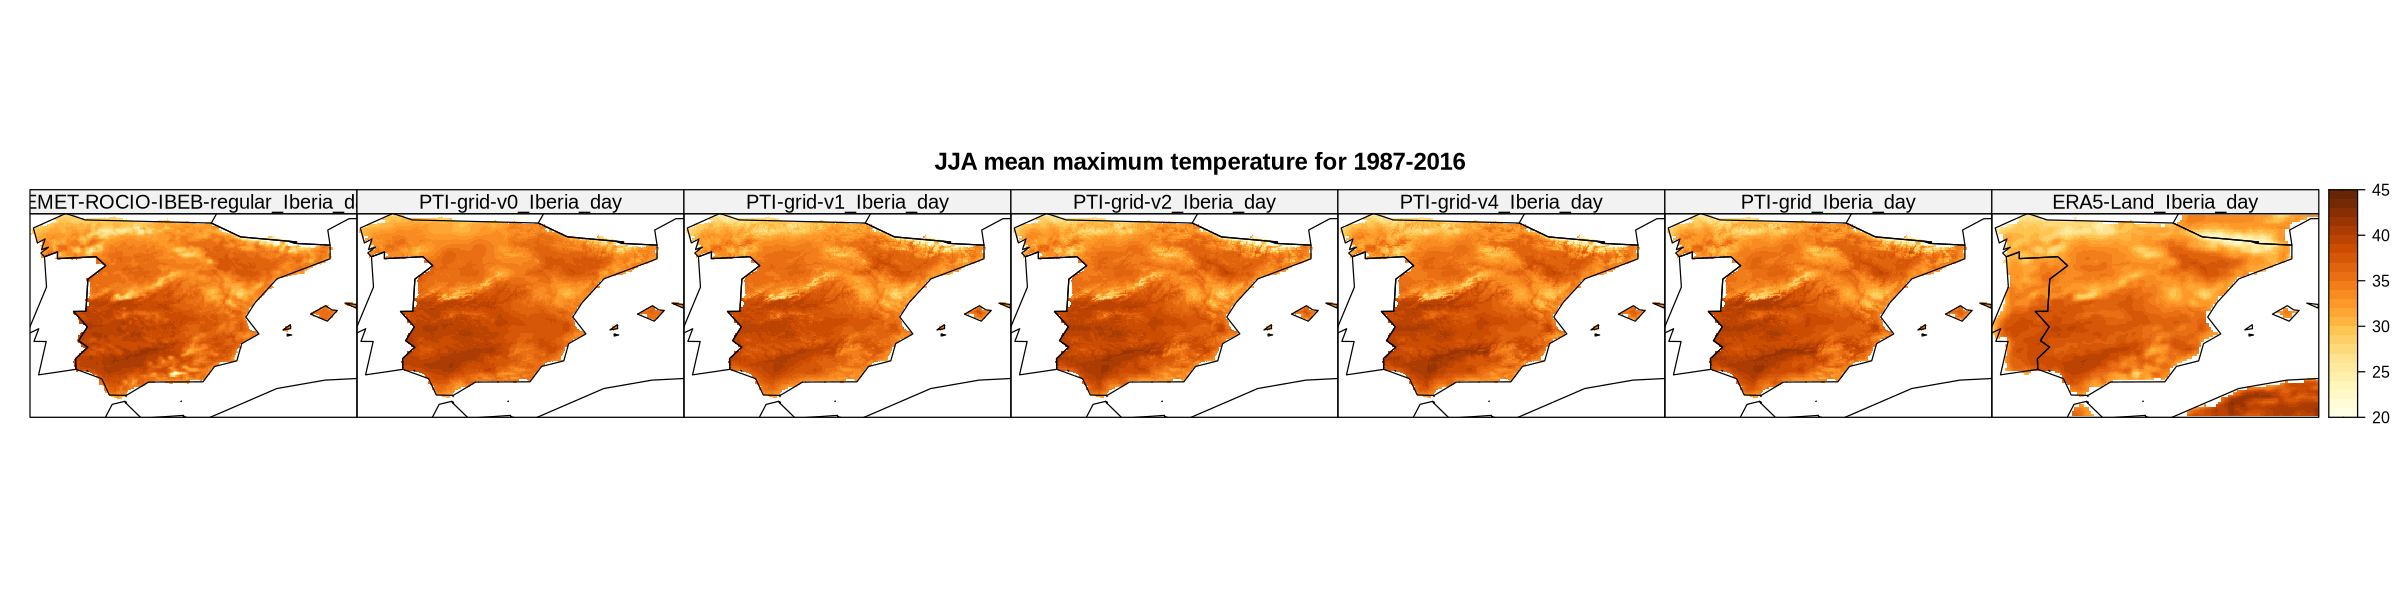

In [26]:
spatialPlot(climatology(tasmax.jja.grid), 
            backdrop.theme = "countries", 
            at = seq(20, 45, 1),
            set.min = 20,
            set.max = 45,
            color.theme = "YlOrBr",
            layout = c(getShape(tasmax.jja.grid, "member"), 1),
            main = "JJA mean maximum temperature for 1987-2016",
            strip = strip.custom(factor.levels = tasmax.jja.grid$Members))

### 5. Análisis básico

#### 5.1. Medias climatológicas

Los mapas que acabamos de crear en la sección anterior, muestran la media estacional (Junio-Julio-Agosto) de las temperaturas máximas mensuales en el periodo 1991-2000. Si queremos visualizar la **media climatológica de las máximas estacionales**, debemos realizar la agregación estacional con la función `aggregateGrid`. Previamente, nos aseguraremos que posibles valores `-Inf` se reconfiguren como `NA`.

In [27]:
tasmax.jja.grid.max <- aggregateGrid(tasmax.jja.grid, aggr.y = list(FUN = "max", na.rm = TRUE)) %>% suppressWarnings

[2026-06-02 13:42:20.744065] Performing annual aggregation...

[2026-06-02 13:45:30.446198] Done.



Posteriormente, nos aseguraremos que posibles valores `-Inf` generados internamente por la función de base `max` se reconfiguren como `NA`.

In [28]:
tasmax.jja.grid.max$Data[which(is.infinite(tasmax.jja.grid.max$Data))] <- NA

[2026-06-02 13:45:43.582457] - Computing climatology...

[2026-06-02 13:45:45.657002] - Done.



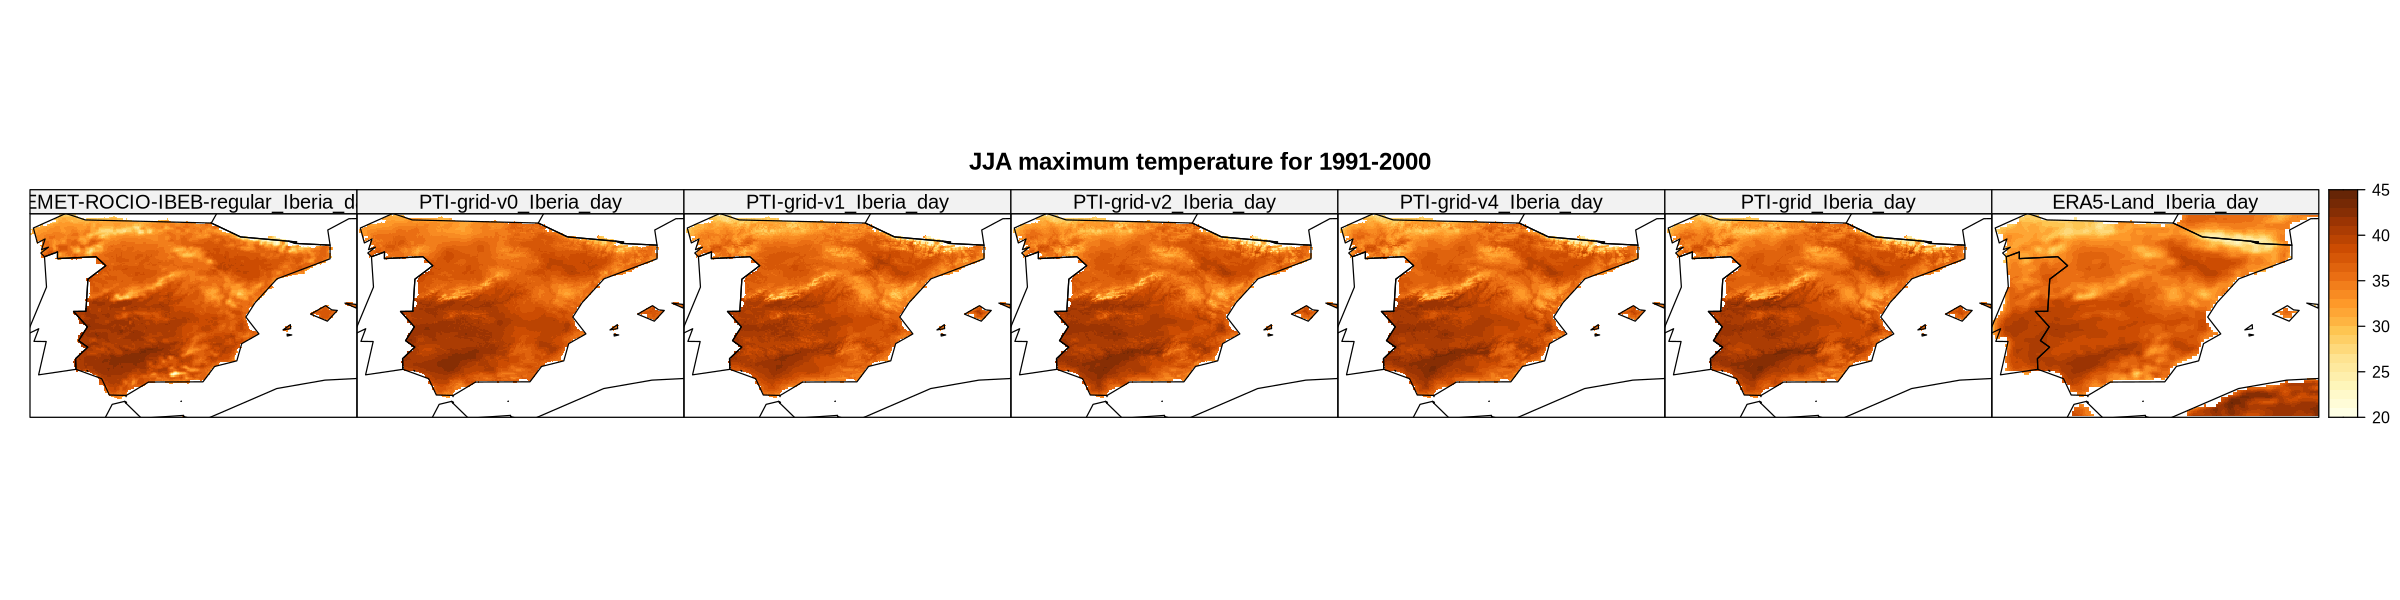

In [29]:
spatialPlot(climatology(tasmax.jja.grid.max), 
            backdrop.theme = "countries", 
            at = seq(20, 45, 1),
            set.min = 20,
            set.max = 45,
            color.theme = "YlOrBr", 
            layout = c(getShape(tasmax.jja.grid.max, "member"), 1),
            main = "JJA maximum temperature for 1991-2000",
            strip = strip.custom(factor.levels = tasmax.jja.grid.max$Members))

Si tomamos uno de los datasets como referencia (en este ejemplo `AEMET-ROCIO-IBEB-regular_Iberia_day`), podemos visualizar los otros mapas como las diferencias con respecto a la referencia. Para calcular estas diferencias utilizamos `gridArithmetics`.

In [35]:
ref <- subsetGrid(tasmax.jja.grid.max, member = 1) %>% climatology %>% suppressMessages
ptiv0 <- subsetGrid(tasmax.jja.grid.max, member = 2) %>% climatology %>% suppressMessages
ptiv1 <- subsetGrid(tasmax.jja.grid.max, member = 3) %>% climatology %>% suppressMessages
ptiv2 <- subsetGrid(tasmax.jja.grid.max, member = 4) %>% climatology %>% suppressMessages
ptiv4 <- subsetGrid(tasmax.jja.grid.max, member = 5) %>% climatology %>% suppressMessages
ptiv5 <- subsetGrid(tasmax.jja.grid.max, member = 6) %>% climatology %>% suppressMessages
era5 <- subsetGrid(tasmax.jja.grid.max, member = 7) %>% climatology %>% suppressMessages

diff.ptiv0 <- gridArithmetics(ptiv0, ref, operator = "-")
diff.ptiv1 <- gridArithmetics(ptiv1, ref, operator = "-")
diff.ptiv2 <- gridArithmetics(ptiv2, ref, operator = "-")
diff.ptiv4 <- gridArithmetics(ptiv4, ref, operator = "-")
diff.ptiv5 <- gridArithmetics(ptiv5, ref, operator = "-")
diff.era5 <- gridArithmetics(era5, ref, operator = "-")
new.aux.grid <- bindGrid(diff.ptiv0, diff.ptiv1, diff.ptiv2, diff.ptiv4, diff.ptiv5, diff.era5, dimension = "member") %>% suppressMessages

In [36]:
a <- spatialPlot(ref, 
            backdrop.theme = "countries", 
            at = seq(20, 45, 1),
            set.min = 20,
            set.max = 45,
            color.theme = "YlOrBr", 
            main = "AEMET-ROCIO-IBEB-regular_Iberia_day")
b <- spatialPlot(new.aux.grid, 
            backdrop.theme = "countries", 
            color.theme = "RdGy", 
            layout = c(3, 1),
            at = seq(-6, 6, 0.2),
            set.max = 6,
            set.min = -6,
            strip = strip.custom(factor.levels = tasmax.jja.grid.max$Members[2:7]))

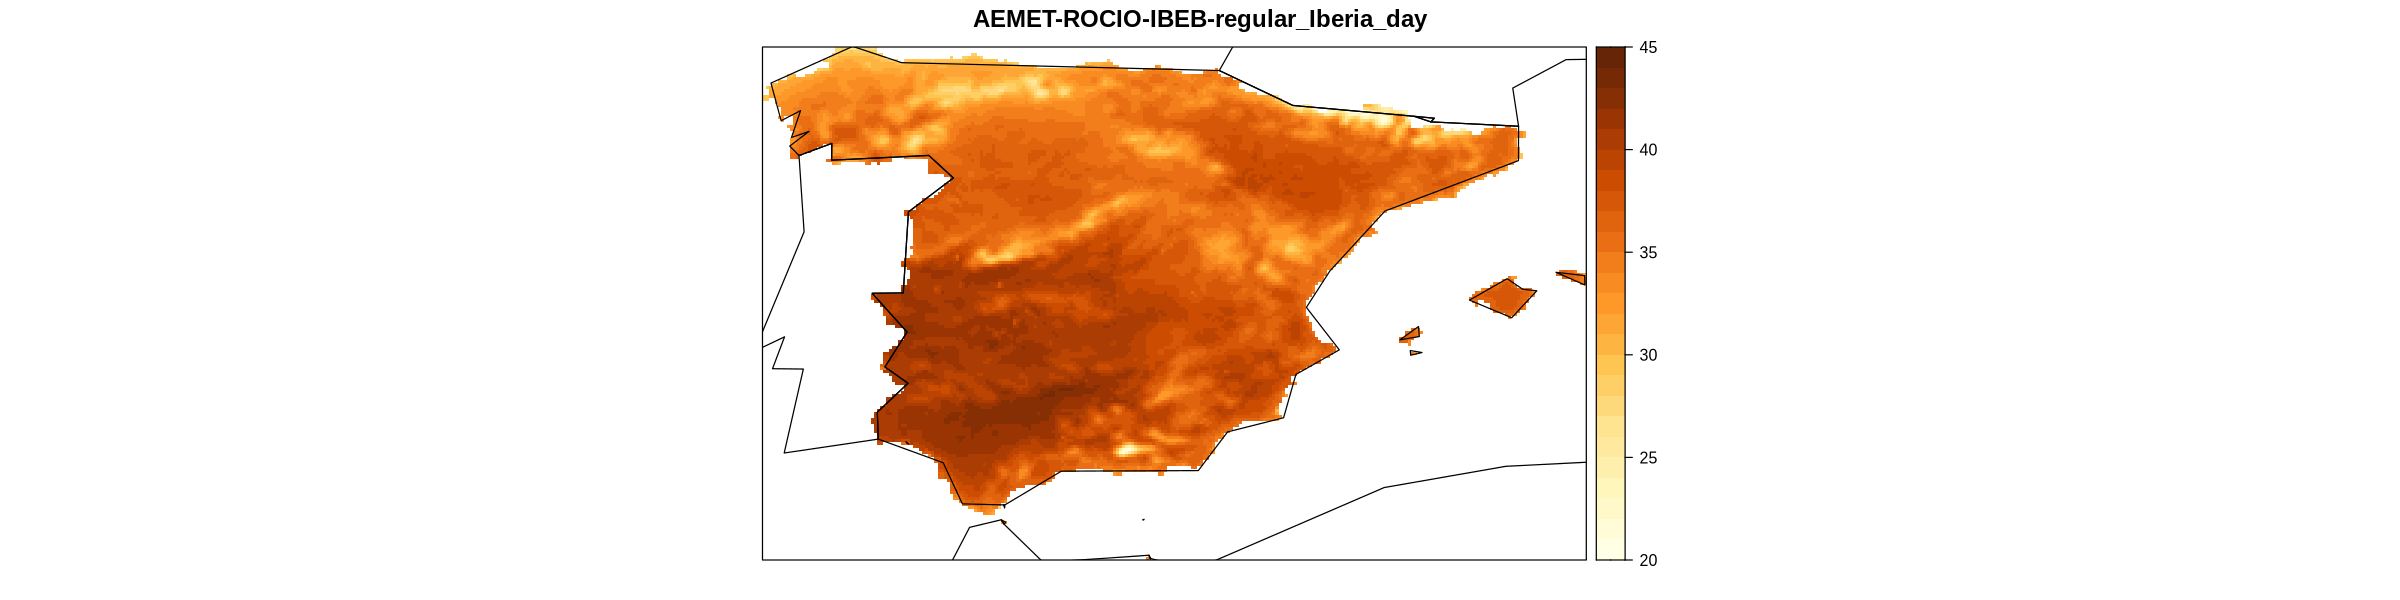

In [37]:
a

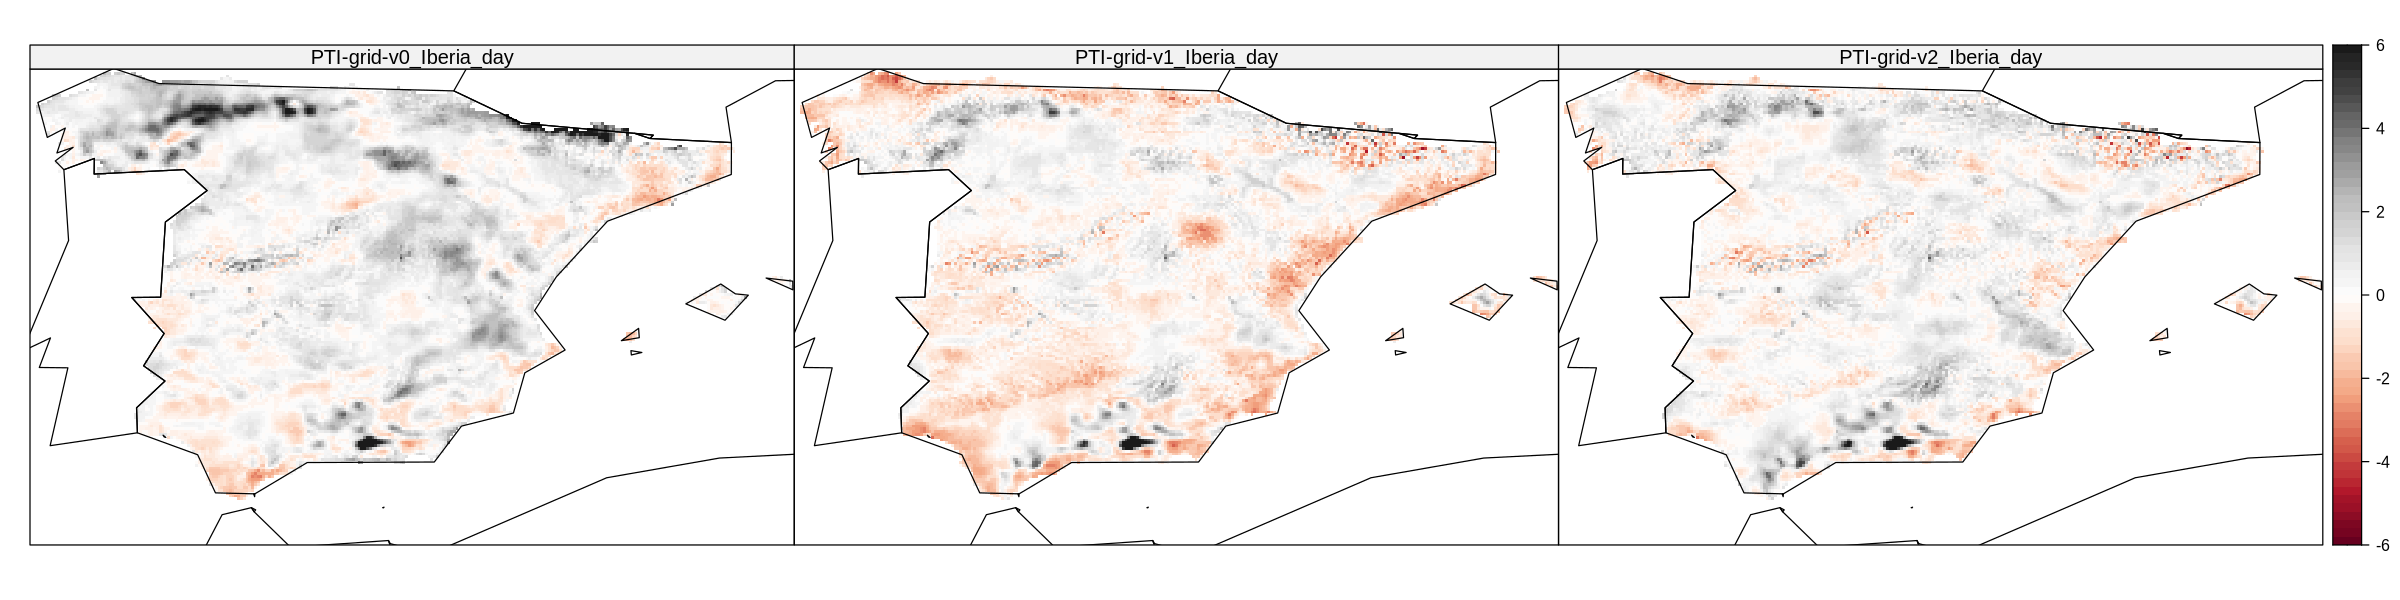

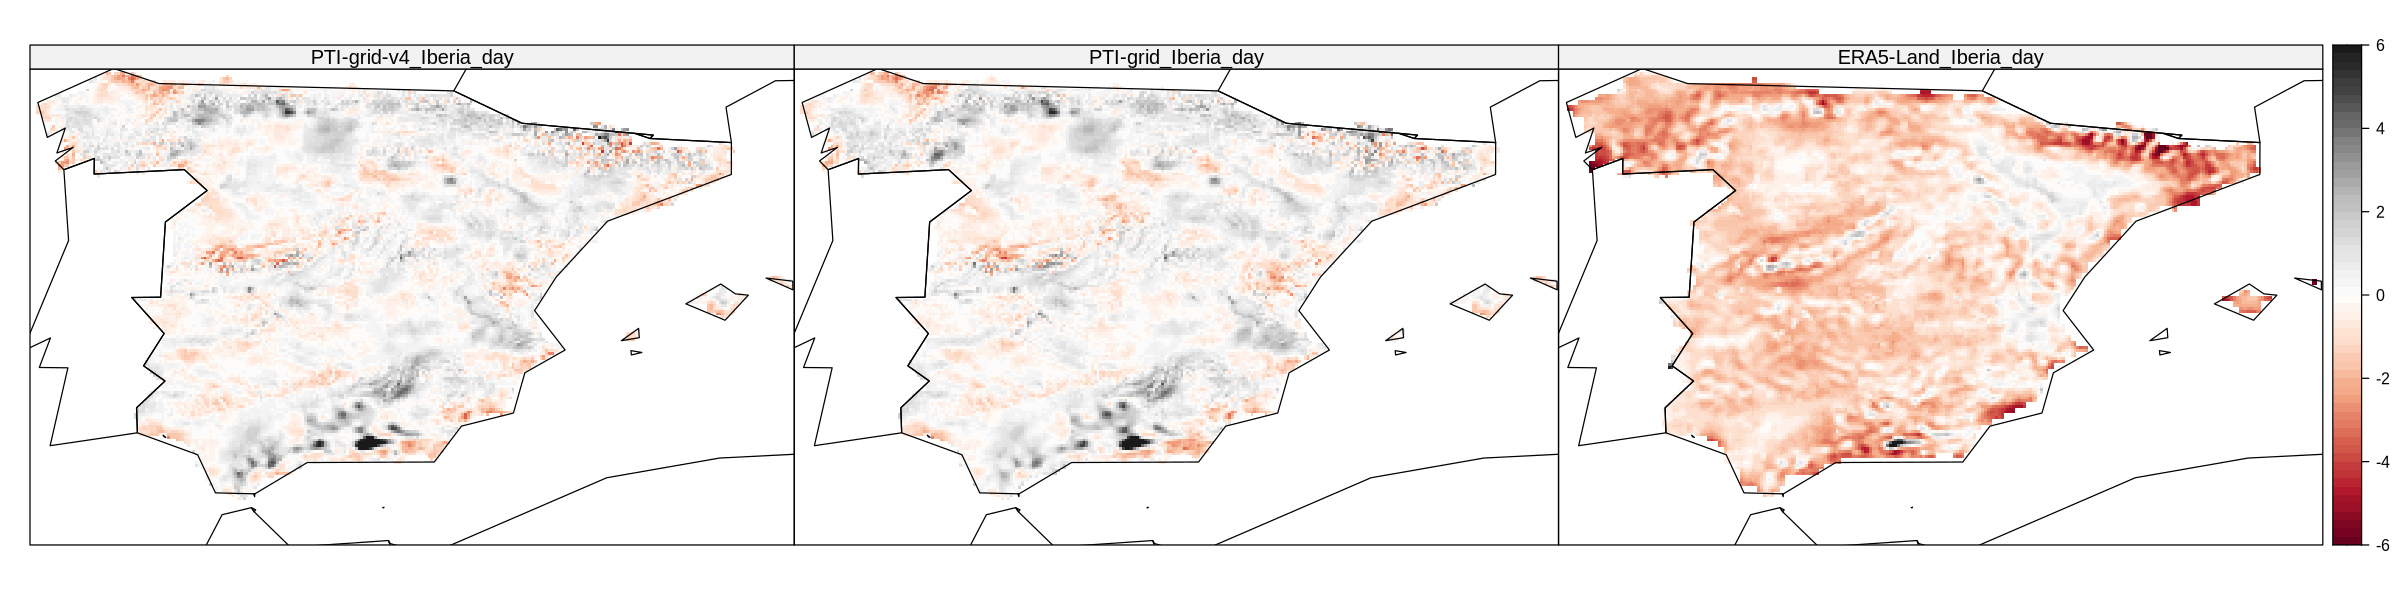

In [38]:
b

#### 5.2. Series temporales

Para ver las **series temporales** de la media espacial aplicaremos la función `temporalPlot`, que internamente realiza la **aggregación espacial** (por defecto la media). Sin embargo, dado que no todos los datasets tienen los valores acotados al territorio español, para que las medias espaciales sean comparables, debemos **aplicar primero una máscara**. Esta máscara la podemos generar a partir del dataset `AEMET-ROCIO-IBEB-regular_Iberia_day` (el miembro en primera posición en nuestro `grid`), que es nuestra referencia en este notebook.

[2026-06-02 13:56:14.655381] - Computing climatology...

[2026-06-02 13:56:14.954731] - Done.



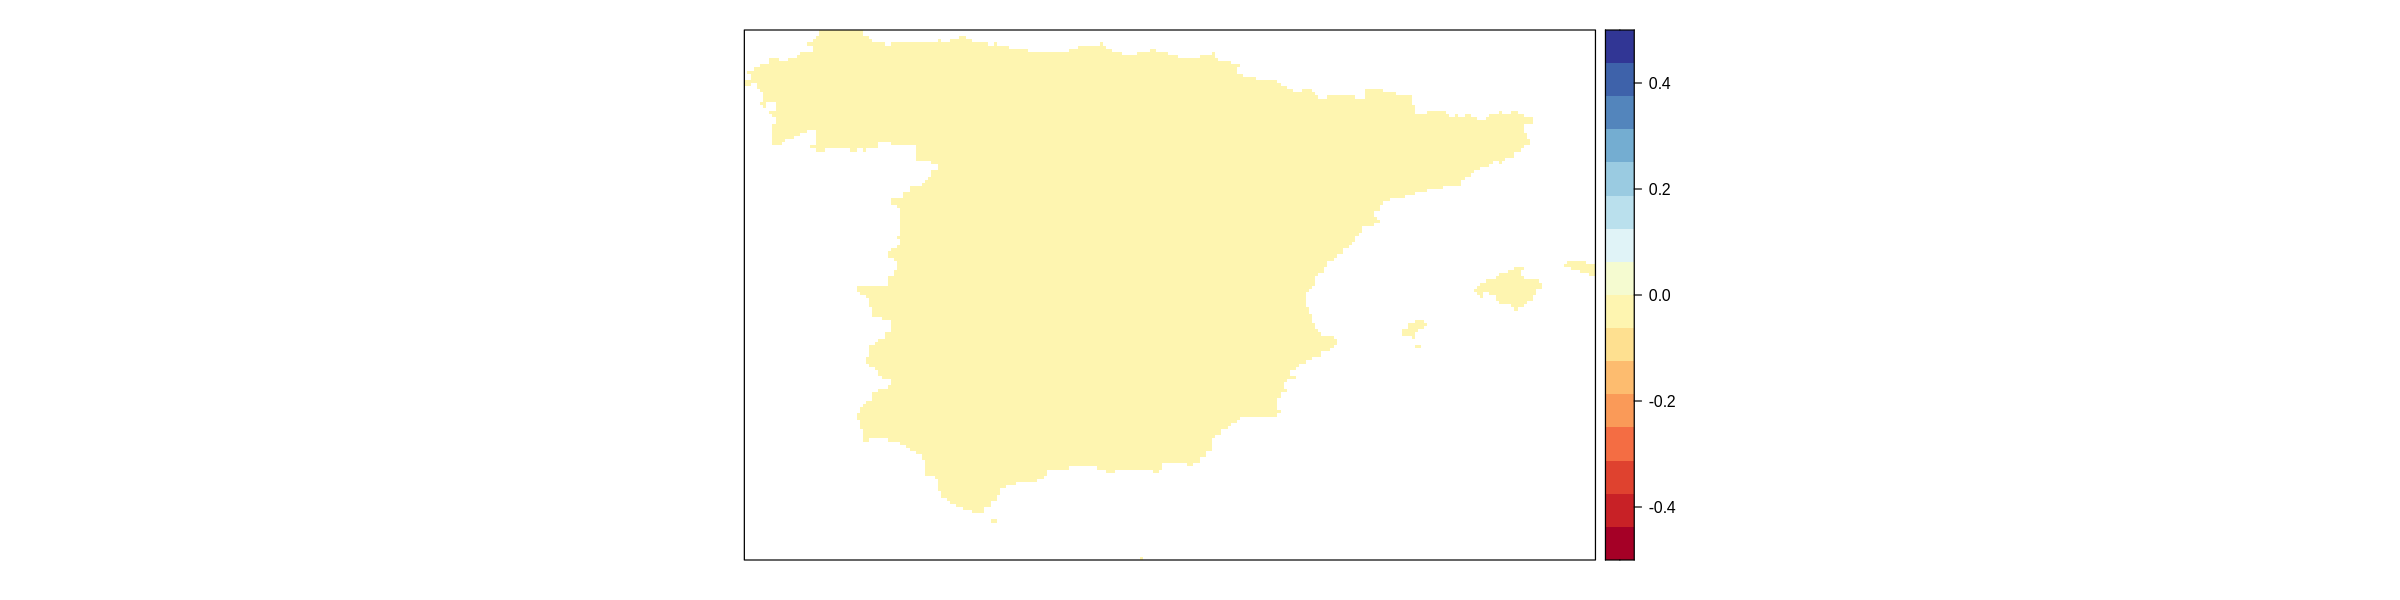

In [39]:
mask <- tasmax.jja.grid.max %>% subsetGrid(members = 1) %>% gridArithmetics(0, operator = "*")
spatialPlot(climatology(mask))

Posteriormente, aplicamos la máscara.

In [40]:
tasmax.jja.grid.max.masked <- gridArithmetics(tasmax.jja.grid.max, rep(list(mask), 
                                                                        getShape(tasmax.jja.grid.max, "member")) %>% bindGrid(dimension = "member"), 
                                               operator = "+") 

Podemos comprobar el resultado volviendo a pintar los mapas.

[2026-06-02 13:57:20.463519] - Computing climatology...

[2026-06-02 13:57:22.396609] - Done.



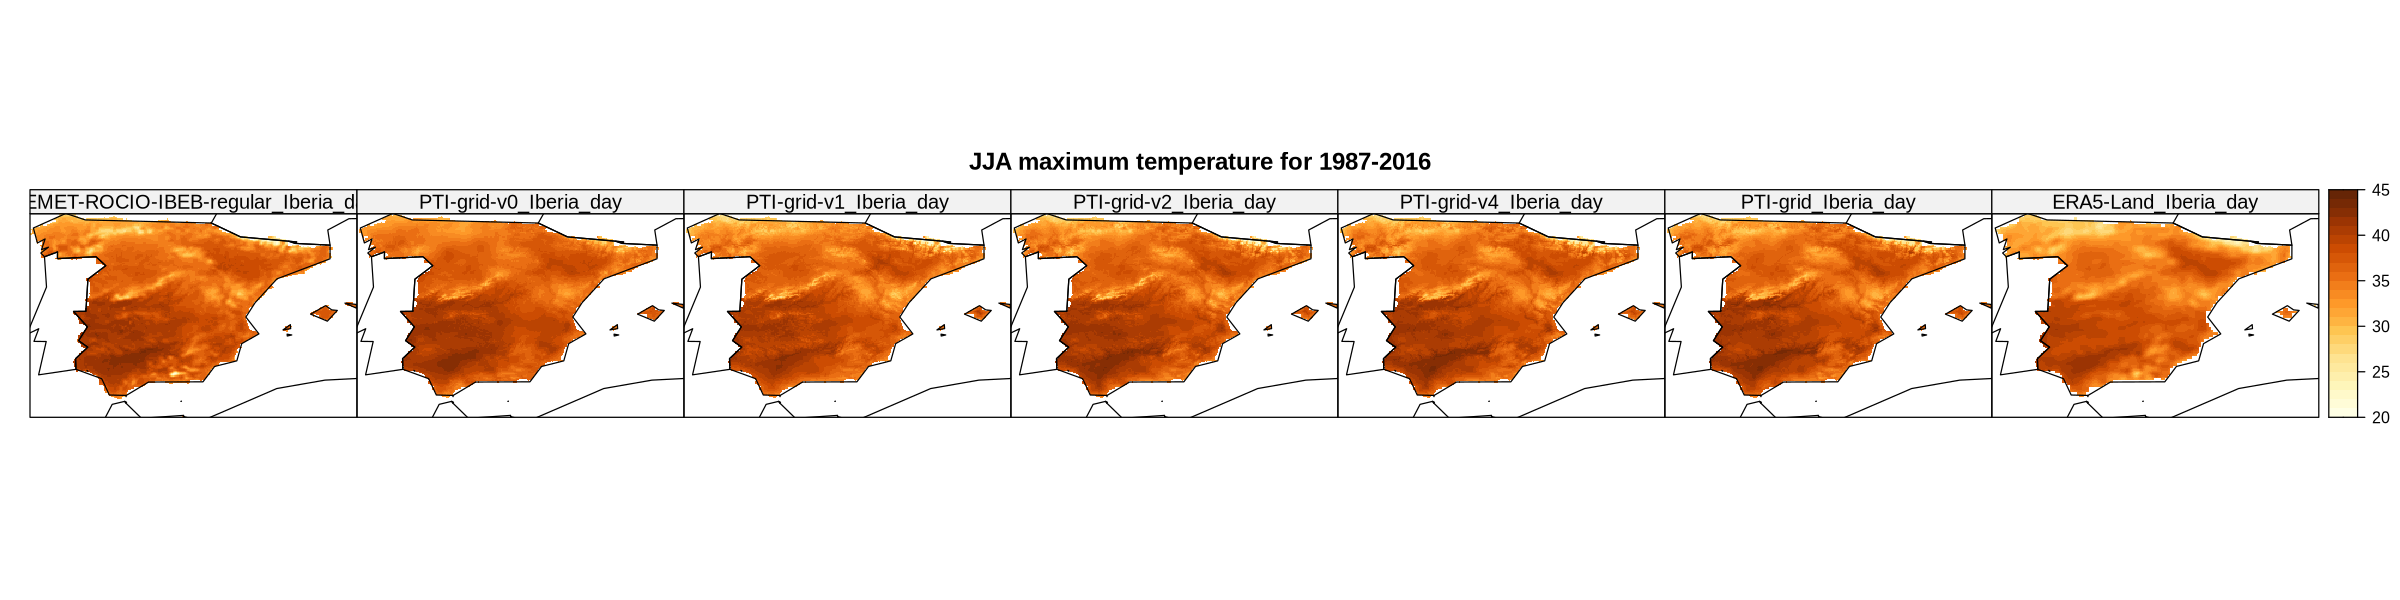

In [41]:
spatialPlot(climatology(tasmax.jja.grid.max.masked), 
            backdrop.theme = "countries", 
            at = seq(20, 45, 1),
            set.min = 20,
            set.max = 45,
            color.theme = "YlOrBr", 
            layout = c(getShape(tasmax.jja.grid.max, "member"), 1),
            main = "JJA maximum temperature for 1987-2016",
            strip = strip.custom(factor.levels = tasmax.jja.grid.max$Members))

Ahora ya podemos comparar las medias regionales. La función `temporalPlot` reconocerá la dimensión miembro del `grid`, y dibujará la media multi-miembro, así como el rango multi-miembro, que se representará como una sombra.

pad applied on the interval: year



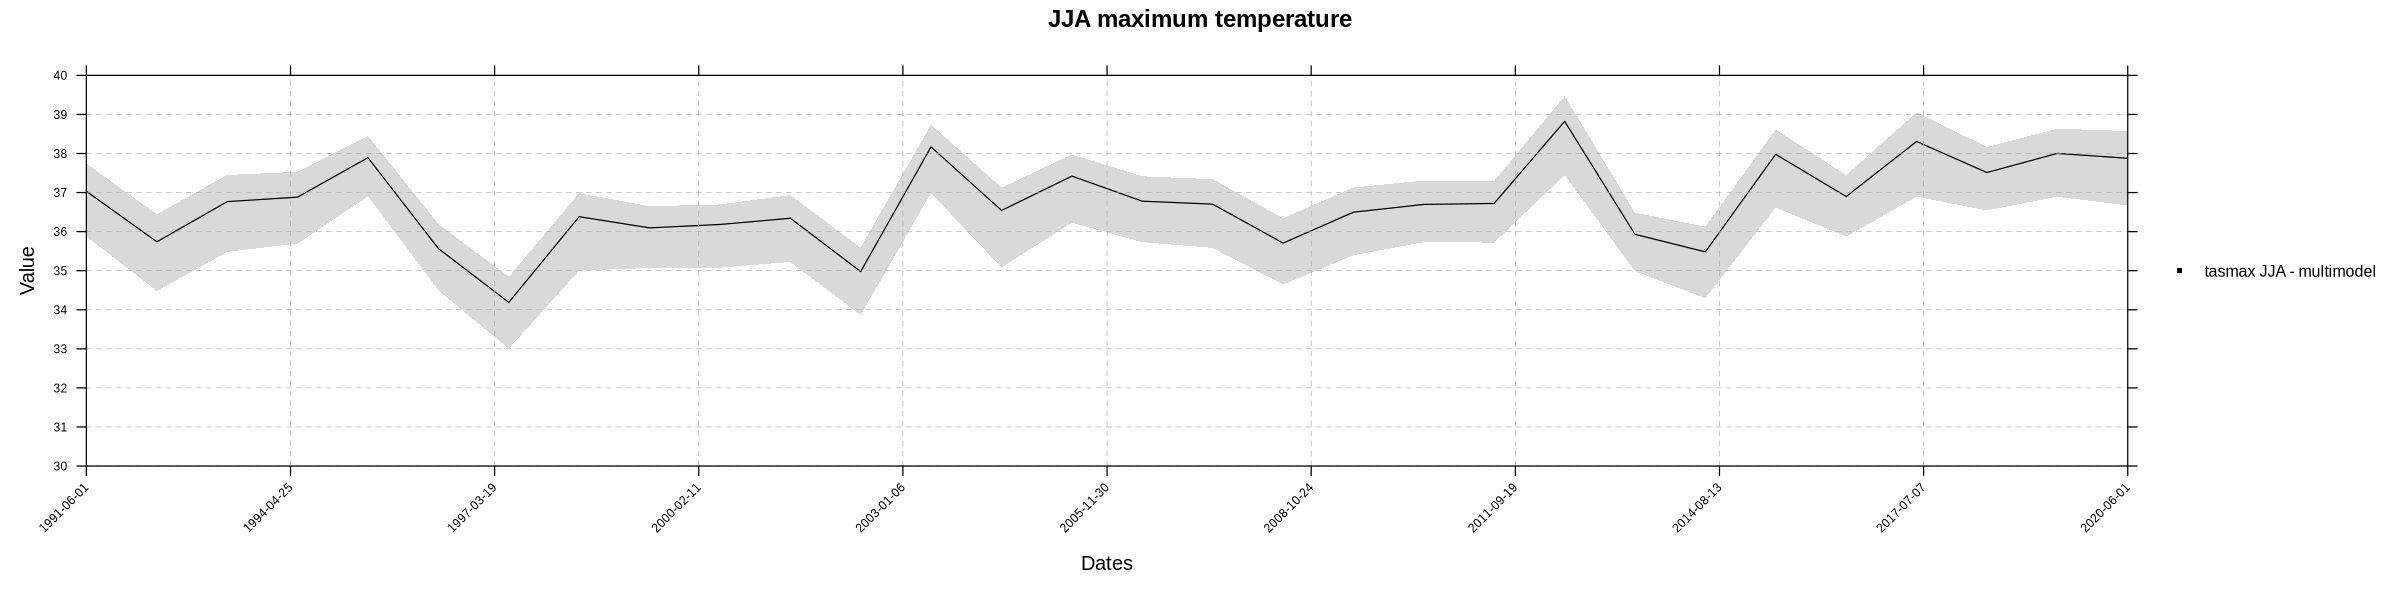

In [42]:
temporalPlot("tasmax JJA - multimodel" = tasmax.jja.grid.max.masked, 
             xyplot.custom = list(ylim = c(30, 40), 
                                  main = "JJA maximum temperature"))

Podemos añadir las series de cada miembro independientemente. Recordemos los nombres de los diferentes miembros:

In [43]:
tasmax.jja.grid.max.masked$Members

[1] "AEMET-ROCIO-IBEB-regular_Iberia_day" "PTI-grid-v0_Iberia_day"             
[3] "PTI-grid-v1_Iberia_day"              "PTI-grid-v2_Iberia_day"             
[5] "PTI-grid-v4_Iberia_day"              "PTI-grid_Iberia_day"                
[7] "ERA5-Land_Iberia_day"

Ahora aplicaremos `subsetGrid` para extraer cada miembro y los añadiremos a `temporalPlot` incluyendo los nombres correspondientes.

pad applied on the interval: year

pad applied on the interval: year

pad applied on the interval: year

pad applied on the interval: year

pad applied on the interval: year

pad applied on the interval: year

pad applied on the interval: year

pad applied on the interval: year



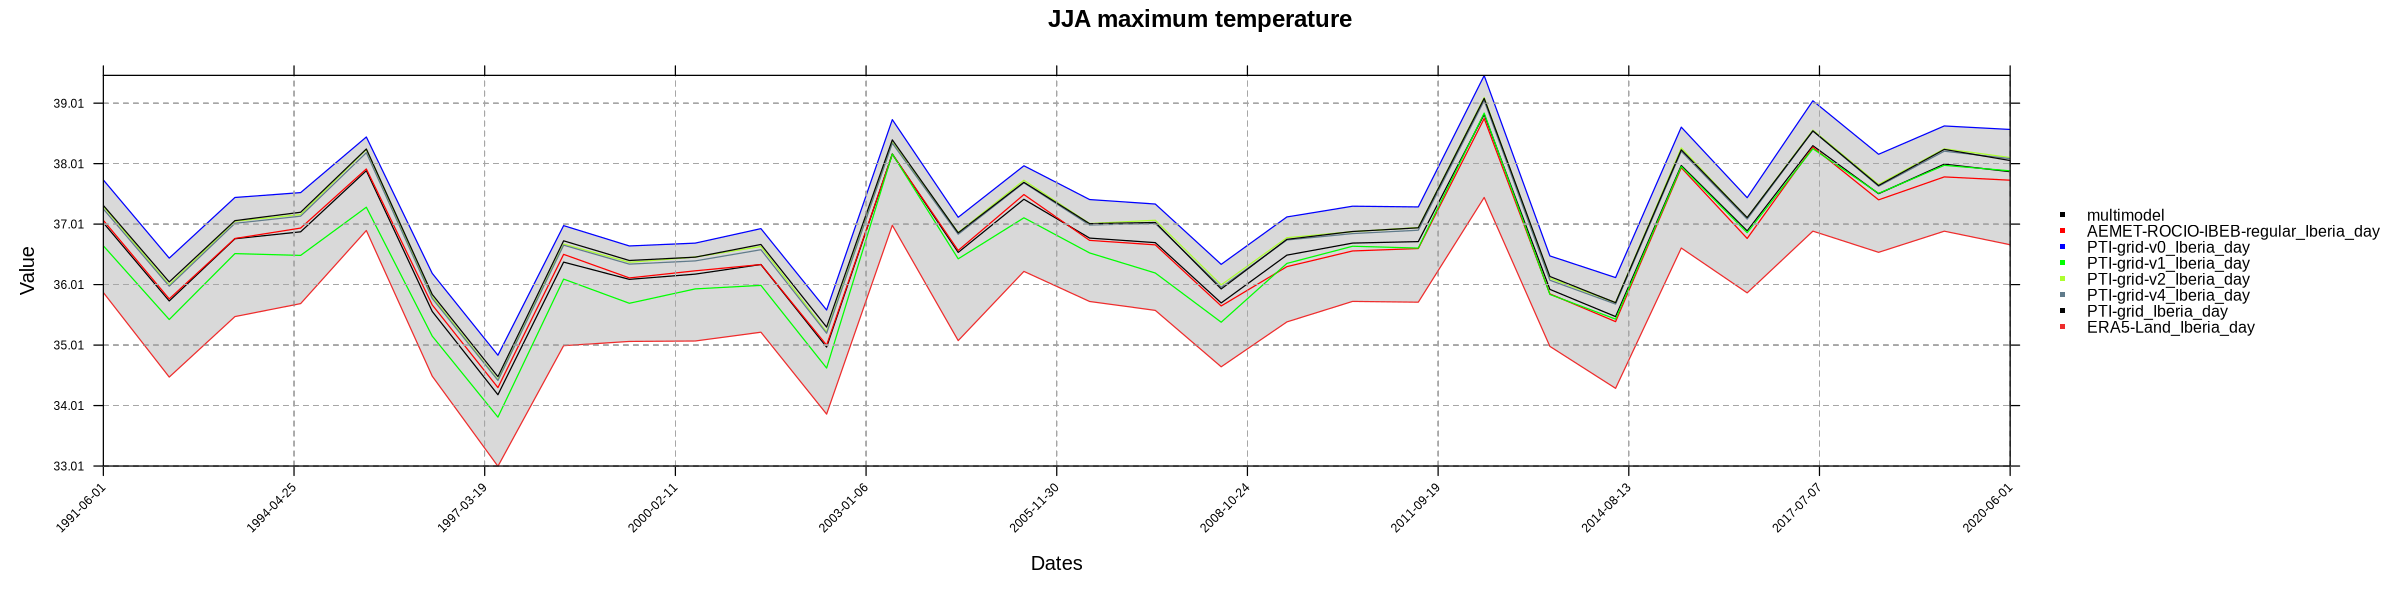

In [44]:
independent.members <- lapply(1:length(datasets$dataset), function(i) subsetGrid(tasmax.jja.grid.max.masked, members = i))

temporalPlot("multimodel" = tasmax.jja.grid.max.masked, 
             "AEMET-ROCIO-IBEB-regular_Iberia_day" = independent.members[[1]],
             "PTI-grid-v0_Iberia_day" = independent.members[[2]],
             "PTI-grid-v1_Iberia_day" = independent.members[[3]],
             "PTI-grid-v2_Iberia_day" = independent.members[[4]],
             "PTI-grid-v4_Iberia_day" = independent.members[[5]],
             "PTI-grid_Iberia_day"    = independent.members[[6]],
             "ERA5-Land_Iberia_day"   = independent.members[[7]],
             xyplot.custom = list(main = "JJA maximum temperature"))

Ejecuta `help(temporalPlot)` para ver todas las posibilidades gráficas que ofrece.

La función que genera la figura de series temporales que hemos utilizado anteriormente realiza automáticamente la agregación espacial de los datos, utilizando la media como función de agregación por defecto y **ponderando los valores según la latitud**. Sin embargo, podemos controlar esta operación utilizando el parámetro `aggr.spatial`, tanto en la función `temporalPlot`, como en la función `aggregateGrid` si queremos generar el objeto agregado. En el siguiente ejemplo, calculamos la máxima espacial:

In [45]:
tasmax.jja.regional.max <- aggregateGrid(tasmax.jja.grid.max.masked, aggr.spatial = list(FUN = "max", na.rm = TRUE))

Spatial weighting skipped: It only applies to 'mean' aggregation function

[2026-06-02 14:01:05.796431] - Aggregating spatially...

[2026-06-02 14:01:06.210701] - Done.



También podemos crear las series temporales del objeto previamente agregado:

pad applied on the interval: year



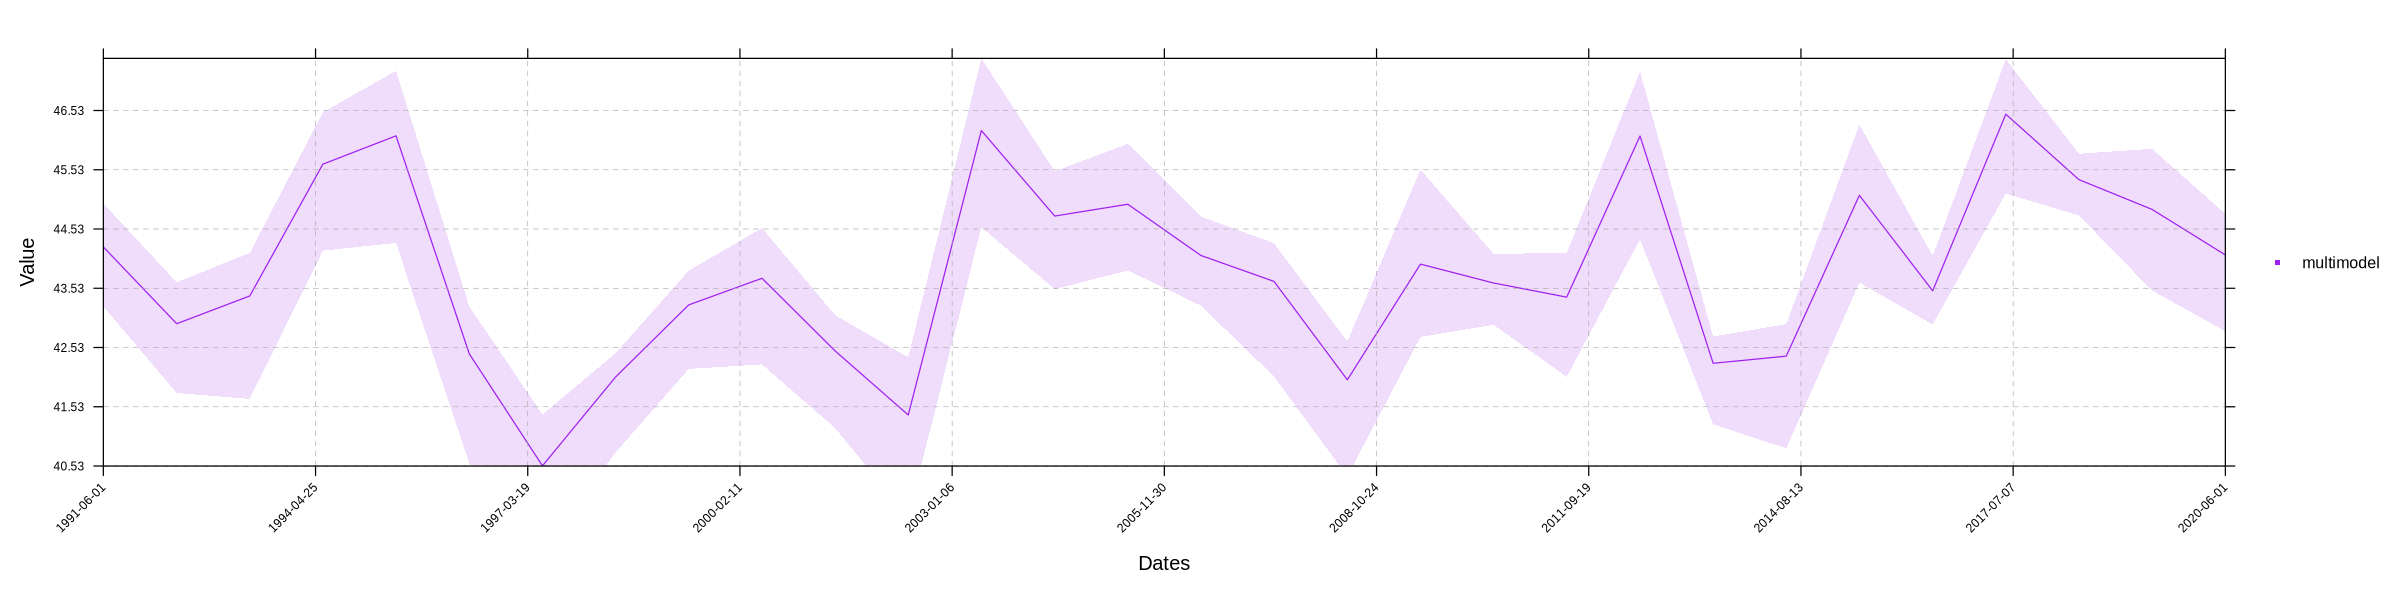

In [46]:
temporalPlot("multimodel" = tasmax.jja.regional.max, cols = "purple")

El **framework *climate4R*** ofrece muchas otras **funcionalidades de operaciones espaciales y temporales**, como **interpolación, subsetting o intersección espacial**. Además, brinda funcionalidades para la **corrección de sesgo y downscaling**. Consulta [Iturbide et al., 2019](https://www.sciencedirect.com/science/article/pii/S1364815218303049?via%3Dihub) y el repositorio de [github de climate4R](https://github.com/SantanderMetGroup/climate4R) para más información.


***

### Session Info

In [47]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.3 LTS

Matrix products: default
BLAS/LAPACK: /opt/conda/envs/climate4r/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8          LC_NUMERIC=C                 
 [3] LC_TIME=en_US.UTF-8           LC_COLLATE=en_US.UTF-8       
 [5] LC_MONETARY=en_US.UTF-8       LC_MESSAGES=en_US.UTF-8      
 [7] LC_PAPER=en_US.UTF-8          LC_NAME=en_US.UTF-8          
 [9] LC_ADDRESS=en_US.UTF-8        LC_TELEPHONE=en_US.UTF-8     
[11] LC_MEASUREMENT=en_US.UTF-8    LC_IDENTIFICATION=en_US.UTF-8

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] gridExtra_2.3       magrittr_2.0.3      lattice_0.22-6     
 [4] visualizeR_1.6.4    transformeR_2.2.2   loadeR_1.8.1       
 [7] climate4R.UDG_0.2.6 loadeR.java_1.1.1   rJava_1.0-11       
[10] repr